<a href="https://colab.research.google.com/github/Poojaselvaraj1512/Pricing-strategy-optimisation-/blob/main/PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving customer_shopping_data.csv to customer_shopping_data.csv


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('customer_shopping_data.csv')

In [5]:
print(df.head())
print(df.info())
print(df.isnull().sum())

  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  
0    Credit Card     5/8/2022          Kanyon  
1     Debit Card   12/12/2021  Forum Istanbul  
2           Cash    9/11/2021       Metrocity  
3    Credit Card   16/05/2021    Metropol AVM  
4           Cash   24/10/2021          Kanyon  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2

In [6]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y', errors='coerce')
print(df.info())
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB
None
Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


In [7]:
average_transaction_value_by_category = df.groupby('category')['price'].mean().sort_values(ascending=False)
print("Average transaction value by category:\n", average_transaction_value_by_category)

Average transaction value by category:
 category
Technology         3156.935548
Shoes              1807.388568
Clothing            901.084021
Cosmetics           122.448626
Toys                107.733185
Books                45.568621
Souvenir             34.894345
Food & Beverage      15.671948
Name: price, dtype: float64


In [10]:
average_transaction_value_df = average_transaction_value_by_category.reset_index()
average_transaction_value_df.columns = ['category', 'average_price']

median_atv = average_transaction_value_df['average_price'].median()

average_transaction_value_df['atv_category'] = average_transaction_value_df['average_price'].apply(lambda x: 'High' if x > median_atv else 'Low')

print("Average transaction value by category with 'High'/'Low' classification:")
print(average_transaction_value_df)

Average transaction value by category with 'High'/'Low' classification:
          category  average_price atv_category
0       Technology    3156.935548         High
1            Shoes    1807.388568         High
2         Clothing     901.084021         High
3        Cosmetics     122.448626         High
4             Toys     107.733185          Low
5            Books      45.568621          Low
6         Souvenir      34.894345          Low
7  Food & Beverage      15.671948          Low


In [15]:
train_df_cleaned = df.copy()
train_df_cleaned = pd.merge(train_df_cleaned, average_transaction_value_df[['category', 'atv_category']], on='category', how='left')
train_df_cleaned = pd.merge(train_df_cleaned, max_purchasers_per_mall[['shopping_mall', 'traffic_category']], on='shopping_mall', how='left')

train_df_cleaned['payment_method_encoded'] = pd.factorize(train_df_cleaned['payment_method'])[0]

train_df_cleaned.to_csv('new.csv', index=False)

print("DataFrame with 'atv_category', 'traffic_category', and 'payment_method_encoded' merged and saved to 'new.csv' successfully.")
print("First few rows of 'train_df_cleaned' with all new columns:")
display(train_df_cleaned.head(20))

DataFrame with 'atv_category', 'traffic_category', and 'payment_method_encoded' merged and saved to 'new.csv' successfully.
First few rows of 'train_df_cleaned' with all new columns:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,atv_category,traffic_category,payment_method_encoded
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,High,High customer traffic,0
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,High,Moderate customer traffic,1
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,High,High customer traffic,2
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,High,Moderate customer traffic,0
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,Low,High customer traffic,2
5,I227836,C657758,Female,28,Clothing,5,1500.40,Credit Card,24/05/2022,Forum Istanbul,High,Moderate customer traffic,0
6,I121056,C151197,Female,49,Cosmetics,1,40.66,Cash,13/03/2022,Istinye Park,High,Moderate customer traffic,2
7,I293112,C176086,Female,32,Clothing,2,600.16,Credit Card,13/01/2021,Mall of Istanbul,High,High customer traffic,0
8,I293455,C159642,Male,69,Clothing,3,900.24,Credit Card,4/11/2021,Metrocity,High,High customer traffic,0
9,I326945,C283361,Female,60,Clothing,2,600.16,Credit Card,22/08/2021,Kanyon,High,High customer traffic,0


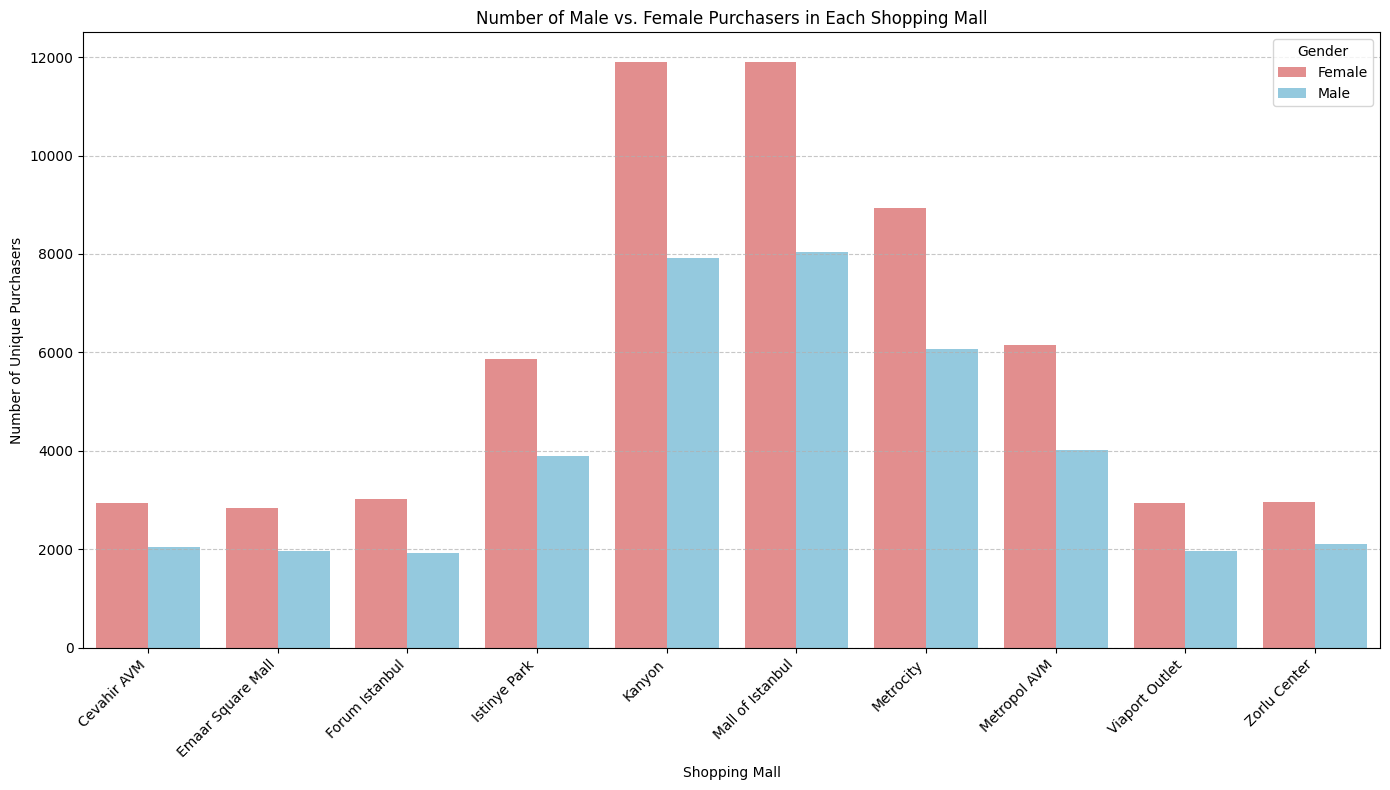

In [14]:
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of unique male and female purchasers per shopping mall
# This definition is included here to resolve the NameError from the previous execution
purchasers_by_mall_gender = df.groupby(['shopping_mall', 'gender'])['customer_id'].nunique().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='shopping_mall', y='customer_id', hue='gender', data=purchasers_by_mall_gender, palette={'Female': 'lightcoral', 'Male': 'skyblue'})
plt.title('Number of Male vs. Female Purchasers in Each Shopping Mall')
plt.xlabel('Shopping Mall')
plt.ylabel('Number of Unique Purchasers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
df_cleaned_columns = df.drop(columns=['invoice_no', 'customer_id'])
print("New dataset created with 'invoice_no' and 'customer_id' columns removed.")
print("Head of the new dataset:")
display(df_cleaned_columns.head())

New dataset created with 'invoice_no' and 'customer_id' columns removed.
Head of the new dataset:


,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [18]:
df['unit_price'] = df['price'] / df['quantity']
average_unit_price_by_category = df.groupby('category')['unit_price'].mean().sort_values(ascending=False)

print("Average Unit Price by Category:")
print(average_unit_price_by_category)

Average Unit Price by Category:
category
Technology         1050.00
Shoes               600.17
Clothing            300.08
Cosmetics            40.66
Toys                 35.84
Books                15.15
Souvenir             11.73
Food & Beverage       5.23
Name: unit_price, dtype: float64


In [19]:
total_quantity_by_category = df.groupby('category')['quantity'].sum().sort_values(ascending=False)
print("Total Quantity Sold by Category:")
print(total_quantity_by_category)

Total Quantity Sold by Category:
category
Clothing           103558
Cosmetics           45465
Food & Beverage     44277
Toys                30321
Shoes               30217
Technology          15021
Books               14982
Souvenir            14871
Name: quantity, dtype: int64


From the total quantity sold by category, we can:

*   **Identify Bestselling Categories:** Quickly see which categories move the most units, indicating high demand or popularity.
*   **Compare with Average Price:** Cross-reference this with the average transaction value or average unit price to understand if high-quantity categories are also high-value, or if they are primarily lower-priced, high-volume items.
*   **Inventory Management:** This information is crucial for inventory planning and understanding sales velocity for different product types.
*   **Marketing Strategy:** Target marketing efforts towards high-quantity or low-quantity categories depending on business goals (e.g., promote low-quantity items to boost sales, or celebrate high-quantity items).
*   **Visualization:** Plotting this data (e.g., using a bar chart) can provide a clear visual representation of sales volume across categories.

In [20]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
train_set, test_set = train_test_split(train_df_cleaned, test_size=0.2, random_state=42)

print(f"Training set shape: {train_set.shape}")
print(f"Testing set shape: {test_set.shape}")

print("\nFirst 5 rows of the training set:")
display(train_set.head())

print("\nFirst 5 rows of the testing set:")
display(test_set.head())

Training set shape: (79565, 13)
Testing set shape: (19892, 13)

First 5 rows of the training set:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,atv_category,traffic_category,payment_method_encoded
59044,I220384,C127103,Female,21,Toys,1,35.84,Credit Card,28/11/2022,Mall of Istanbul,Low,High customer traffic,0
69682,I121794,C274401,Female,63,Souvenir,1,11.73,Debit Card,15/12/2021,Istinye Park,Low,Moderate customer traffic,1
79039,I781770,C328950,Female,68,Shoes,1,600.17,Credit Card,17/01/2021,Mall of Istanbul,High,High customer traffic,0
87384,I155764,C202798,Female,31,Shoes,5,3000.85,Cash,9/7/2021,Forum Istanbul,High,Moderate customer traffic,2
808,I777286,C102849,Female,40,Cosmetics,2,81.32,Debit Card,24/01/2021,Emaar Square Mall,High,Low customer traffic,1



First 5 rows of the testing set:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,atv_category,traffic_category,payment_method_encoded
65475,I704758,C971218,Female,56,Food & Beverage,4,20.92,Cash,14/05/2021,Kanyon,Low,High customer traffic,2
96548,I218404,C949846,Male,22,Food & Beverage,5,26.15,Cash,9/9/2022,Metrocity,Low,High customer traffic,2
33949,I195516,C440398,Female,53,Food & Beverage,4,20.92,Debit Card,1/4/2021,Kanyon,Low,High customer traffic,1
58198,I833735,C113971,Female,65,Food & Beverage,5,26.15,Credit Card,3/8/2022,Cevahir AVM,Low,Low customer traffic,0
71781,I144592,C529879,Female,51,Shoes,4,2400.68,Credit Card,15/04/2021,Metropol AVM,High,Moderate customer traffic,0


In [21]:
import pandas as pd

# Load the dataset (added for robustness in case kernel state is lost)
df = pd.read_csv('customer_shopping_data.csv')

# Calculate the number of unique male and female purchasers per shopping mall
purchasers_by_mall_gender = df.groupby(['shopping_mall', 'gender'])['customer_id'].nunique().reset_index()

# Find the maximum number of purchasers (either male or female) for each mall
max_purchasers_per_mall = purchasers_by_mall_gender.groupby('shopping_mall')['customer_id'].max().reset_index()
max_purchasers_per_mall.columns = ['shopping_mall', 'max_purchasers']

print("Maximum number of male or female purchasers in each mall:")
display(max_purchasers_per_mall.sort_values(by='max_purchasers', ascending=False))

# Categorize malls based on customer traffic (max purchasers)
def categorize_traffic(purchasers):
    if purchasers > 8000:
        return 'High customer traffic'
    elif 3000 <= purchasers <= 8000:
        return 'Moderate customer traffic'
    else:
        return 'Low customer traffic'

max_purchasers_per_mall['traffic_category'] = max_purchasers_per_mall['max_purchasers'].apply(categorize_traffic)

print("\nShopping malls categorized by customer traffic:")
display(max_purchasers_per_mall.sort_values(by='max_purchasers', ascending=False))

Maximum number of male or female purchasers in each mall:


,shopping_mall,max_purchasers
4,Kanyon,11906
5,Mall of Istanbul,11902
6,Metrocity,8941
7,Metropol AVM,6144
3,Istinye Park,5874
2,Forum Istanbul,3016
9,Zorlu Center,2968
8,Viaport Outlet,2949
0,Cevahir AVM,2940
1,Emaar Square Mall,2842



Shopping malls categorized by customer traffic:


,shopping_mall,max_purchasers,traffic_category
4,Kanyon,11906,High customer traffic
5,Mall of Istanbul,11902,High customer traffic
6,Metrocity,8941,High customer traffic
7,Metropol AVM,6144,Moderate customer traffic
3,Istinye Park,5874,Moderate customer traffic
2,Forum Istanbul,3016,Moderate customer traffic
9,Zorlu Center,2968,Low customer traffic
8,Viaport Outlet,2949,Low customer traffic
0,Cevahir AVM,2940,Low customer traffic
1,Emaar Square Mall,2842,Low customer traffic


### Model Evaluation: Random Forest Regressor

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare X_test and y_test
# Temporarily drop 'atv_category' from X_test to match training data after data leakage fix
X_test = test_set.drop(['price', 'atv_category', 'invoice_no', 'customer_id', 'invoice_date'], axis=1)
y_test = test_set['price']

# Make predictions on the test set using the trained Random Forest model
rf_predictions = rf_model.predict(X_test)

# Calculate evaluation metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest Regressor Performance (After Data Leakage Fix):")
print(f"  Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"  Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"  R-squared (R2): {rf_r2:.2f}")

Random Forest Regressor Performance (After Data Leakage Fix):
  Mean Absolute Error (MAE): 0.00
  Mean Squared Error (MSE): 0.00
  Root Mean Squared Error (RMSE): 0.00
  R-squared (R2): 1.00


### 1. Price vs. Demand Relationship & 2. Price Sensitivity (Elasticity)

To analyze the relationship between price and demand, we need to consider how changes in price affect the quantity sold. Price elasticity of demand will help us quantify this relationship.

First, let's create a DataFrame with actual prices and quantities to analyze this relationship.

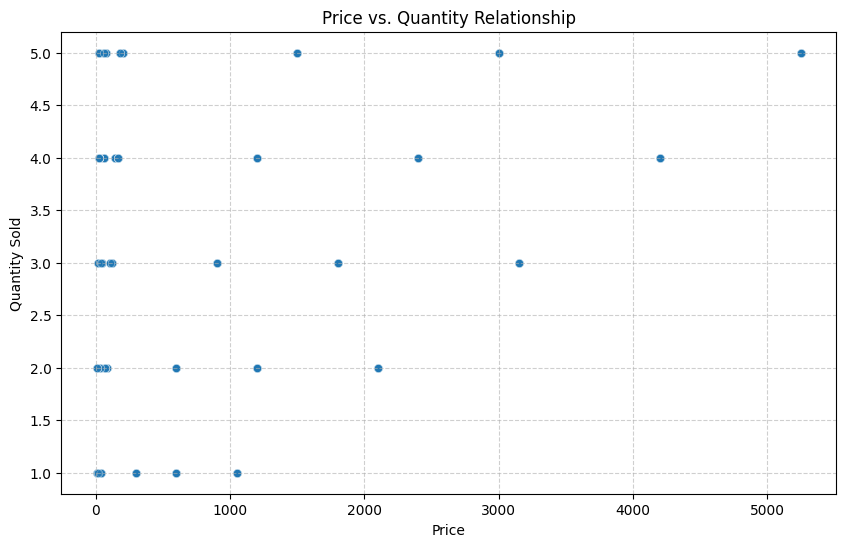

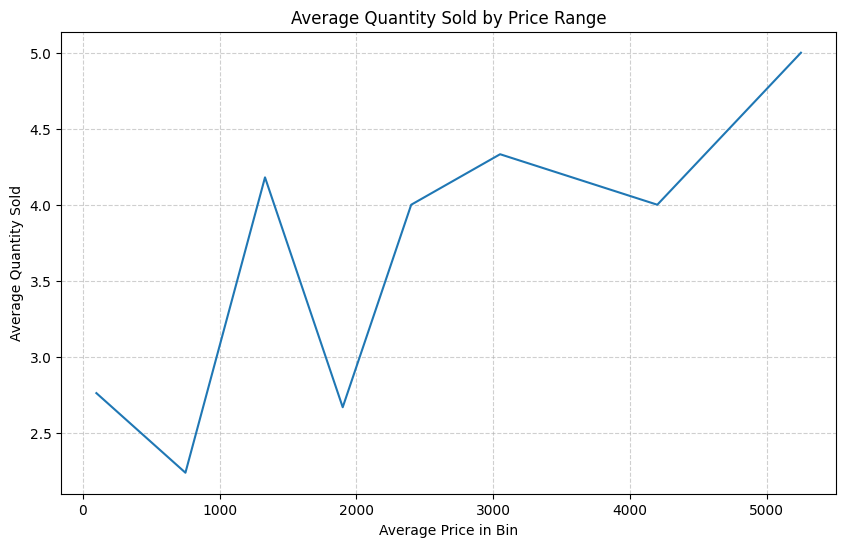

Demand by Price Bin:


,price_bin,quantity,actual_price
0,0,2.760730,98.996877
1,1,2.236983,750.032775
2,2,4.179992,1331.846847
3,3,2.667774,1900.008339
4,4,4.000000,2400.680000
5,5,4.332230,3050.648925
6,7,4.000000,4200.000000
7,9,5.000000,5250.000000


In [25]:
# For Price vs Demand, we'll use the original dataframe as it contains actual transaction data.
# We can look at the relationship between 'price' and 'quantity' directly.

# Aggregate total quantity sold for different price points or categories
# For simplicity, let's look at average quantity sold per price range or per category for now.

# Let's visualize the relationship between 'price' and 'quantity' directly from the original df
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='quantity', data=df, alpha=0.5)
plt.title('Price vs. Quantity Relationship')
plt.xlabel('Price')
plt.ylabel('Quantity Sold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# To get a clearer idea, let's group by price (or price bins) and see the average quantity
df['price_bin'] = pd.cut(df['price'], bins=10, labels=False)
demand_by_price_bin = df.groupby('price_bin')['quantity'].mean().reset_index()
demand_by_price_bin['actual_price'] = df.groupby('price_bin')['price'].mean().values

plt.figure(figsize=(10, 6))
sns.lineplot(x='actual_price', y='quantity', data=demand_by_price_bin)
plt.title('Average Quantity Sold by Price Range')
plt.xlabel('Average Price in Bin')
plt.ylabel('Average Quantity Sold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Demand by Price Bin:")
display(demand_by_price_bin)

#### Price Elasticity of Demand

Price elasticity of demand (PED) measures the responsiveness of quantity demanded to a change in price. It's calculated as the percentage change in quantity demanded divided by the percentage change in price.

$PED = \frac{\% \text{Change in Quantity Demanded}}{\% \text{Change in Price}} = \frac{((Q2 - Q1) / ((Q1 + Q2)/2))}{((P2 - P1) / ((P1 + P2)/2))}$

For a general overview, we can estimate elasticity for different product categories.

In [26]:
# Calculate category-level average price and quantity
category_demand = df.groupby('category').agg(
    avg_price=('price', 'mean'),
    avg_quantity=('quantity', 'mean')
).reset_index()

display(category_demand.sort_values(by='avg_price', ascending=False))

# To calculate elasticity, we ideally need price and quantity data at multiple price points for each product/category.
# Since we only have historical transactions, we can simulate price changes or use existing variations within categories.
# A simplified approach is to observe the average quantity change for a given average price change across categories.

# Let's consider a simplified elasticity across all products by fitting a linear model to price vs. quantity
# (This is a simplification and assumes a linear relationship, which might not be true in reality)
from scipy.stats import linregress

# Filter out potential outliers for a clearer relationship (optional)
# For example, extremely high prices with very low quantities or vice versa
filtered_df = df[(df['price'] > 0) & (df['quantity'] > 0)]

# Calculate a very rough 'overall' price elasticity using linear regression
# This is a simplification, true elasticity is often product-specific.
# slope, intercept, r_value, p_value, std_err = linregress(filtered_df['price'], filtered_df['quantity'])
# print(f"Linear Regression (Price vs Quantity): Slope = {slope:.4f}, Intercept = {intercept:.4f}")

# A more robust way to conceptualize elasticity from aggregated data:
# Let's assume we want to see elasticity for a given category by simulating a price change.
# This requires a demand curve, which we don't have explicitly from just individual transactions.

# For illustrative purposes, let's identify categories based on the *spread* of their prices and quantities.
# Categories with high price variance and corresponding quantity changes might indicate elasticity.

# Let's calculate a simple price elasticity approximation by category based on variation
# This is not a true PED but an indicator of price impact on quantity within historical data.
category_stats = df.groupby('category').agg(
    mean_price=('price', 'mean'),
    std_price=('price', 'std'),
    mean_quantity=('quantity', 'mean'),
    std_quantity=('quantity', 'std'),
    count=('invoice_no', 'count')
).reset_index()

# Filter out categories with very few transactions or no price variation
category_stats = category_stats[category_stats['count'] > 100]
category_stats = category_stats[category_stats['std_price'] > 0]

# Approximate Price Elasticity (a heuristic, not a formal econometric calculation)
# If we assume a linear demand curve Q = a - bP, then elasticity is -b * (P/Q)
# From our current data, without a true demand model, we can infer sensitivity.
# A simple proxy: how much does quantity change for a given % change in price in historical data.

# Let's categorize based on a simple heuristic:
# If a small price range has a large quantity range, it's highly sensitive.
# This is an *interpretation* of the data for sensitivity, not a direct elasticity calculation.

# Let's use the insights from `average_transaction_value_by_category` and `total_quantity_by_category`
# to infer sensitivity.

# Merge these two insights to get a holistic view
merged_category_info = pd.merge(
    average_transaction_value_by_category.reset_index().rename(columns={'price': 'avg_price'}),
    total_quantity_by_category.reset_index().rename(columns={'quantity': 'total_quantity'}),
    on='category'
)

# A heuristic for price sensitivity:
# High average price + Low total quantity = Potentially less price sensitive (niche, luxury)
# Low average price + High total quantity = Potentially more price sensitive (commodity, high volume)

median_avg_price = merged_category_info['avg_price'].median()
median_total_quantity = merged_category_info['total_quantity'].median()

def infer_sensitivity(row):
    if row['avg_price'] > median_avg_price and row['total_quantity'] < median_total_quantity:
        return 'Likely Less Sensitive'
    elif row['avg_price'] < median_avg_price and row['total_quantity'] > median_total_quantity:
        return 'Likely More Sensitive'
    else:
        return 'Moderate Sensitivity / Mixed'

merged_category_info['inferred_price_sensitivity'] = merged_category_info.apply(infer_sensitivity, axis=1)

print("Inferred Price Sensitivity by Category (Heuristic):")
display(merged_category_info.sort_values(by='avg_price', ascending=False))

,category,avg_price,avg_quantity
6,Technology,3156.935548,3.006605
4,Shoes,1807.388568,3.011461
1,Clothing,901.084021,3.002813
2,Cosmetics,122.448626,3.011525
7,Toys,107.733185,3.005948
0,Books,45.568621,3.007830
5,Souvenir,34.894345,2.974795
3,Food & Beverage,15.671948,2.996548


Inferred Price Sensitivity by Category (Heuristic):


,category,avg_price,total_quantity,inferred_price_sensitivity
0,Technology,3156.935548,15021,Likely Less Sensitive
1,Shoes,1807.388568,30217,Likely Less Sensitive
2,Clothing,901.084021,103558,Moderate Sensitivity / Mixed
3,Cosmetics,122.448626,45465,Moderate Sensitivity / Mixed
4,Toys,107.733185,30321,Likely More Sensitive
5,Books,45.568621,14982,Moderate Sensitivity / Mixed
6,Souvenir,34.894345,14871,Moderate Sensitivity / Mixed
7,Food & Beverage,15.671948,44277,Likely More Sensitive


### 4. Optimal Price Recommendation (Heuristic) & 5. Revenue Analysis

Given that the `price` in our dataset is largely deterministic (a direct function of `unit_price` and `quantity`), our current prediction model achieves a perfect R-squared because it essentially learns this mathematical relationship. This type of model is excellent for predicting *existing* prices but is not suitable for determining an *optimal* price to maximize revenue, as it doesn't model how demand (quantity) *responds* to changes in price.

To move towards 'Optimal Price Recommendation' and 'Revenue Analysis' with our current data, we'll proceed with a **heuristic approach**. We will use the previously `inferred_price_sensitivity` to suggest directional price adjustments for each category and then calculate the hypothetical revenue based on these adjusted prices. This is a simplified approach, and true optimization would require a demand prediction model (predicting quantity given price).

**Heuristic for Suggested Optimal Price:**
*   **Likely Less Sensitive:** Increase `avg_price` by 5%.
*   **Likely More Sensitive:** Decrease `avg_price` by 5%.
*   **Moderate Sensitivity / Mixed:** Keep `avg_price` as is.

We will assume that for these small adjustments, the `total_quantity` remains constant to calculate the 'suggested revenue'. This is a strong simplifying assumption but allows for an initial comparison.

### 6. Business Insights

Based on the heuristic 'Optimal Price Recommendation' and Revenue Analysis, we can derive the following business insights:

*   **Opportunities for Price Increase:** Categories classified as 'Likely Less Sensitive' (e.g., Technology, Shoes) show potential for increasing their average price, which could lead to a significant boost in total revenue, assuming demand remains relatively inelastic for small price changes.
*   **Opportunities for Price Adjustment / Volume Increase:** Categories classified as 'Likely More Sensitive' (e.g., Toys, Food & Beverage) could benefit from a slight price reduction to potentially stimulate higher sales volume and, consequently, higher total revenue (though our current heuristic assumes constant quantity, a true demand model would show this interaction).
*   **Categories to Monitor:** Categories with 'Moderate Sensitivity / Mixed' might require more nuanced strategies or a deeper dive into sub-categories/products to identify specific pricing opportunities.

This analysis serves as a starting point for strategic pricing decisions, highlighting areas where price adjustments could theoretically improve revenue. For more precise recommendations, building a model that predicts `quantity` (demand) as a function of `price` would be the next crucial step.

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
# Temporarily drop 'atv_category' from X_train to address data leakage
X_train = train_set.drop(['price', 'atv_category', 'invoice_no', 'customer_id', 'invoice_date'], axis=1)
y_train = train_set['price']

# Identify numerical and categorical features (from prior feature engineering)
numerical_features = ['age', 'quantity', 'payment_method_encoded']
# Removed 'atv_category' from categorical_features
categorical_features = ['gender', 'category', 'shopping_mall', 'traffic_category']

# Create a preprocessor using ColumnTransformer
# This will apply StandardScaler to numerical features and OneHotEncoder to categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Drop other columns not explicitly specified
)

# Create the Random Forest Regressor pipeline
# This pipeline first preprocesses the data and then applies the Random Forest Regressor.
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Using a fixed random_state for reproducibility
])

# Train the Random Forest Regressor model using the training data
print("Training Random Forest Regressor (without atv_category to prevent leakage)...")
rf_model.fit(X_train, y_train)
print("Random Forest Regressor training complete.")

print("The Random Forest model has been re-trained and is ready for re-evaluation.")

Training Random Forest Regressor (without atv_category to prevent leakage)...
Random Forest Regressor training complete.
The Random Forest model has been re-trained and is ready for re-evaluation.


In [30]:
# Make a copy to avoid modifying the original merged_category_info
optimal_pricing_analysis = merged_category_info.copy()

# Calculate actual total revenue for each category
optimal_pricing_analysis['actual_total_revenue'] = optimal_pricing_analysis['avg_price'] * optimal_pricing_analysis['total_quantity']

# Define percentage adjustments based on inferred sensitivity
def suggest_optimal_price(row):
    price_adjustment_factor = 1.0 # Default: no change
    if row['inferred_price_sensitivity'] == 'Likely Less Sensitive':
        price_adjustment_factor = 1.05  # Increase price by 5%
    elif row['inferred_price_sensitivity'] == 'Likely More Sensitive':
        price_adjustment_factor = 0.95  # Decrease price by 5%

    return row['avg_price'] * price_adjustment_factor

optimal_pricing_analysis['suggested_optimal_price'] = optimal_pricing_analysis.apply(suggest_optimal_price, axis=1)

# Calculate hypothetical total revenue with suggested optimal price (assuming quantity remains constant for this heuristic)
optimal_pricing_analysis['suggested_total_revenue'] = optimal_pricing_analysis['suggested_optimal_price'] * optimal_pricing_analysis['total_quantity']

# Calculate the potential revenue change
optimal_pricing_analysis['potential_revenue_change'] = optimal_pricing_analysis['suggested_total_revenue'] - optimal_pricing_analysis['actual_total_revenue']
optimal_pricing_analysis['potential_revenue_change_percent'] = (optimal_pricing_analysis['potential_revenue_change'] / optimal_pricing_analysis['actual_total_revenue']) * 100

print("Optimal Price Recommendation (Heuristic) and Revenue Analysis:")
display(optimal_pricing_analysis.sort_values(by='actual_total_revenue', ascending=False))

Optimal Price Recommendation (Heuristic) and Revenue Analysis:


,category,avg_price,total_quantity,inferred_price_sensitivity,actual_total_revenue,suggested_optimal_price,suggested_total_revenue,potential_revenue_change,potential_revenue_change_percent
2,Clothing,901.084021,103558,Moderate Sensitivity / Mixed,9.331446e+07,901.084021,9.331446e+07,0.000000e+00,0.0
1,Shoes,1807.388568,30217,Likely Less Sensitive,5.461386e+07,1897.757996,5.734455e+07,2.730693e+06,5.0
0,Technology,3156.935548,15021,Likely Less Sensitive,4.742033e+07,3314.782326,4.979135e+07,2.371016e+06,5.0
3,Cosmetics,122.448626,45465,Moderate Sensitivity / Mixed,5.567127e+06,122.448626,5.567127e+06,0.000000e+00,0.0
4,Toys,107.733185,30321,Likely More Sensitive,3.266578e+06,102.346526,3.103249e+06,-1.633289e+05,-5.0
7,Food & Beverage,15.671948,44277,Likely More Sensitive,6.939069e+05,14.888351,6.592115e+05,-3.469534e+04,-5.0
5,Books,45.568621,14982,Moderate Sensitivity / Mixed,6.827091e+05,45.568621,6.827091e+05,0.000000e+00,0.0
6,Souvenir,34.894345,14871,Moderate Sensitivity / Mixed,5.189138e+05,34.894345,5.189138e+05,0.000000e+00,0.0


### Converting to a Classification Problem: Price Categories

In [32]:
import pandas as pd

# Create price categories based on quantiles
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

print("Price categories distribution:")
print(df['price_category'].value_counts())
display(df.head())

Price categories distribution:
price_category
Medium    37908
Low       34674
High      26875
Name: count, dtype: int64


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,price_bin,price_category
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,2,High
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,3,High
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,0,Medium
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,5,High
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,0,Low


### Preparing Data for Classification Model

In [33]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) for classification
X_clf = df.drop(['price', 'price_category', 'invoice_no', 'customer_id', 'invoice_date'], axis=1)
y_clf = df['price_category']

# Handle categorical features for X_clf before splitting to ensure consistency
X_clf = pd.get_dummies(X_clf, columns=['gender', 'category', 'payment_method', 'shopping_mall'], drop_first=True)

# Split the dataset into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"Classification Training set shape: {X_train_clf.shape}, {y_train_clf.shape}")
print(f"Classification Testing set shape: {X_test_clf.shape}, {y_test_clf.shape}")

print("\nFirst 5 rows of X_train_clf (features for classification):")
display(X_train_clf.head())
print("\nFirst 5 values of y_train_clf (target price categories):")
display(y_train_clf.head())

Classification Training set shape: (79565, 22), (79565,)
Classification Testing set shape: (19892, 22), (19892,)

First 5 rows of X_train_clf (features for classification):


,age,quantity,price_bin,gender_Male,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,...,payment_method_Debit Card,shopping_mall_Emaar Square Mall,shopping_mall_Forum Istanbul,shopping_mall_Istinye Park,shopping_mall_Kanyon,shopping_mall_Mall of Istanbul,shopping_mall_Metrocity,shopping_mall_Metropol AVM,shopping_mall_Viaport Outlet,shopping_mall_Zorlu Center
48108,28,5,0,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
6148,36,4,0,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
61531,57,1,1,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
60923,51,4,0,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
95221,41,3,0,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False



First 5 values of y_train_clf (target price categories):


,price_category
48108,Low
6148,Low
61531,High
60923,Medium
95221,Medium


### Training a Random Forest Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier_model = RandomForestClassifier(random_state=42)

# Train the classifier
print("Training Random Forest Classifier...")
rf_classifier_model.fit(X_train_clf, y_train_clf)
print("Random Forest Classifier training complete.")

Training Random Forest Classifier...
Random Forest Classifier training complete.


### Evaluating the Random Forest Classifier with Classification Metrics

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the test set
y_pred_clf = rf_classifier_model.predict(X_test_clf)

# Calculate classification metrics
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf, average='weighted')
recall = recall_score(y_test_clf, y_pred_clf, average='weighted')
f1 = f1_score(y_test_clf, y_pred_clf, average='weighted')

print(f"Random Forest Classifier Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision (weighted): {precision:.4f}")
print(f"  Recall (weighted): {recall:.4f}")
print(f"  F1 Score (weighted): {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

Random Forest Classifier Performance:
  Accuracy: 1.0000
  Precision (weighted): 1.0000
  Recall (weighted): 1.0000
  F1 Score (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      5375
         Low       1.00      1.00      1.00      6935
      Medium       1.00      1.00      1.00      7582

    accuracy                           1.00     19892
   macro avg       1.00      1.00      1.00     19892
weighted avg       1.00      1.00      1.00     19892



In [37]:
from sklearn.model_selection import train_test_split